In [ ]:
!pip install keras-tuner -q

In [ ]:
# Cell 1: Imports
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from google.colab import drive
import os
from keras import regularizers
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Cell 2: Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cell 3: Define paths
base_dir = '/content/drive/MyDrive/ASL_Images'

In [ ]:
# Cell 4: Data Preprocessing
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32,
    label_mode='categorical'
)

classes = train_ds.class_names

Found 956 files belonging to 5 classes.
Using 765 files for training.
Found 956 files belonging to 5 classes.
Using 191 files for validation.


In [ ]:
# hyperparameter tuning
'''
def build_model(hp):
    model = models.Sequential()
    hp_filters = hp.Int('filters', min_value=32, max_value=128, step=32)
    model.add(layers.Conv2D(hp_filters, (3, 3), activation='relu', input_shape=(128, 128, 3)))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())
    hp_units = hp.Int('units', min_value=64, max_value=256, step=64)
    model.add(layers.Dense(units=hp_units, activation='relu'))
    hp_dropout = hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)
    model.add(layers.Dropout(rate=hp_dropout))
    model.add(layers.Dense(5, activation='softmax'))
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

tuner = kt.Hyperband(build_model,
                      objective='val_accuracy',
                      max_epochs=10,
                      factor=3,
                      directory='my_dir',
                      project_name='intro_to_kt')

tuner.search(train_ds, epochs=10, validation_data=val_ds)
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Optimal filters: {best_hps.get('filters')}")
print(f"Optimal dense units: {best_hps.get('units')}")
print(f"Optimal dropout: {best_hps.get('dropout')}")
print(f"Optimal learning rate: {best_hps.get('learning_rate')}")
'''

In [ ]:
# Cell 5: Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
    layers.RandomZoom(0.1),
])

In [ ]:
# Cell 6: Build the CNN
# Improved CNN with 3 blocks and dropout
# Use your hyperparameter variables
MY_FILTERS = 16
MY_UNITS = 64
MY_DROPOUT = 0.4
MY_LR = 0.0005
MY_L2 = 0.01      # Gentler regularization

model = models.Sequential([
    layers.InputLayer(input_shape=(128, 128, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(MY_FILTERS, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(MY_FILTERS * 2, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(MY_FILTERS * 4, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((4, 4)),

    # Flatten
    layers.Flatten(),

    # The "Simple" part of the model
    layers.Dense(MY_UNITS, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(MY_L2)),
    layers.Dropout(MY_DROPOUT),
    layers.Dense(5, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=MY_LR),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.F1Score(average='macro', name='f1_score')
    ]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 286,565 (1.09 MB)

 Trainable params: 286,341 (1.09 MB)

 Non-trainable params: 224 (896.00 B)

In [ ]:
# Cell 7: Training
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5, # If val_loss doesn't improve for 5 epochs, stop!
    restore_best_weights=True # Give me the version before it started overfitting
)

print("Training model...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks = [early_stop],
    verbose=1)
print("Training complete!")

Training model...
Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.2784 - f1_score: 0.2570 - loss: 3.3163 - val_accuracy: 0.1780 - val_f1_score: 0.1181 - val_loss: 2.8066
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.2889 - f1_score: 0.2578 - loss: 2.7186 - val_accuracy: 0.1832 - val_f1_score: 0.0619 - val_loss: 2.8966
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.3922 - f1_score: 0.3546 - loss: 2.5404 - val_accuracy: 0.1832 - val_f1_score: 0.0619 - val_loss: 3.0807
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.4641 - f1_score: 0.4225 - loss: 2.3330 - val_accuracy: 0.1832 - val_f1_score: 0.0619 - val_loss: 3.0775
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.5163 - f1_score: 0.4866 - loss: 2.1456 - val_accuracy: 0.1832 - val_f1_score: 0.0619 - val_loss: 2.9724
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.5425 - f1_score: 0.5095 - loss: 2.0079 - val_accuracy: 0.2932 - val_f1_score: 

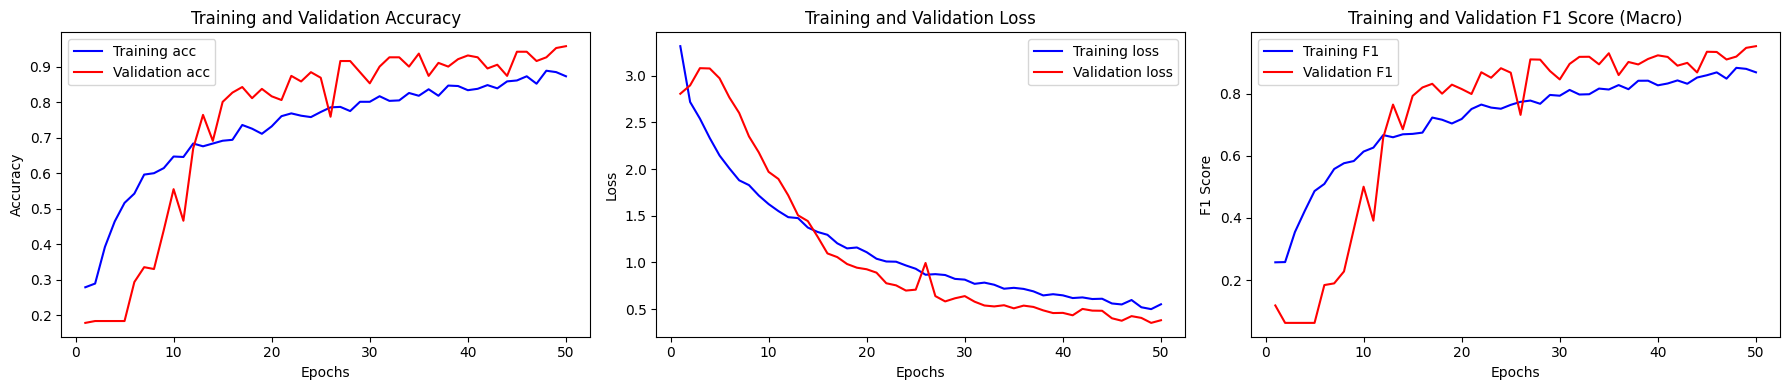

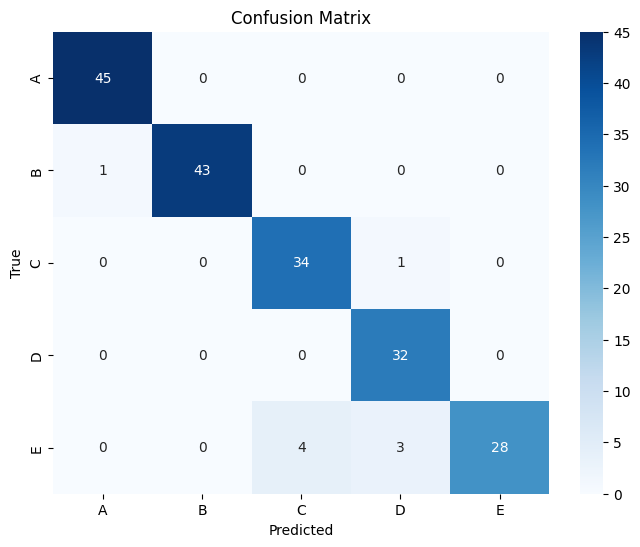

Best validation accuracy: 95.81%
Best validation F1 score: 0.9533
📊 Generating Classification Report...

==================== CLASSIFICATION REPORT ====================
              precision    recall  f1-score   support

           A       0.98      1.00      0.99        45
           B       1.00      0.98      0.99        44
           C       0.89      0.97      0.93        35
           D       0.89      1.00      0.94        32
           E       1.00      0.80      0.89        35

    accuracy                           0.95       191
   macro avg       0.95      0.95      0.95       191
weighted avg       0.96      0.95      0.95       191



In [ ]:
# Cell 8: Visualizations
def plot_training(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    f1 = history.history['f1_score']
    val_f1 = history.history['val_f1_score']
    epochs = range(1, len(acc)+1)

    plt.figure(figsize=(18,4))

    plt.subplot(1,3,1)
    plt.plot(epochs, acc, 'b-', label='Training acc')
    plt.plot(epochs, val_acc, 'r-', label='Validation acc')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,3,2)
    plt.plot(epochs, loss, 'b-', label='Training loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1,3,3)
    plt.plot(epochs, f1, 'b-', label='Training F1')
    plt.plot(epochs, val_f1, 'r-', label='Validation F1')
    plt.title('Training and Validation F1 Score (Macro)')
    plt.xlabel('Epochs')
    plt.ylabel('F1 Score')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training(history)

def plot_confusion_matrix(model, dataset, class_names):
    all_preds = []
    all_labels = []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        all_preds.extend(np.argmax(preds, axis=1))
        all_labels.extend(np.argmax(labels.numpy(), axis=1))
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(model, val_ds, classes)

# Final metrics
best_val_f1 = max(history.history['val_f1_score'])
best_val_acc = max(history.history['val_accuracy'])
print(f"Best validation accuracy: {best_val_acc*100:.2f}%")
print(f"Best validation F1 score: {best_val_f1:.4f}")

# Get Predictions and True Labels
print("📊 Generating Classification Report...")
y_true = []
y_pred = []

# Iterate through validation set to get true values and predictions
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# Print the Classification Report
# 'classes' should be ['A', 'B', 'C', 'D', 'E']
report = classification_report(y_true, y_pred, target_names=classes)
print("\n" + "="*20 + " CLASSIFICATION REPORT " + "="*20)
print(report)
print("="*63)

Found 49 files belonging to 5 classes.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step - accuracy: 0.2449 - f1_score: 0.1887 - loss: 6.1503
Test accuracy: 24.49%
Test F1 score: 0.1887
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step


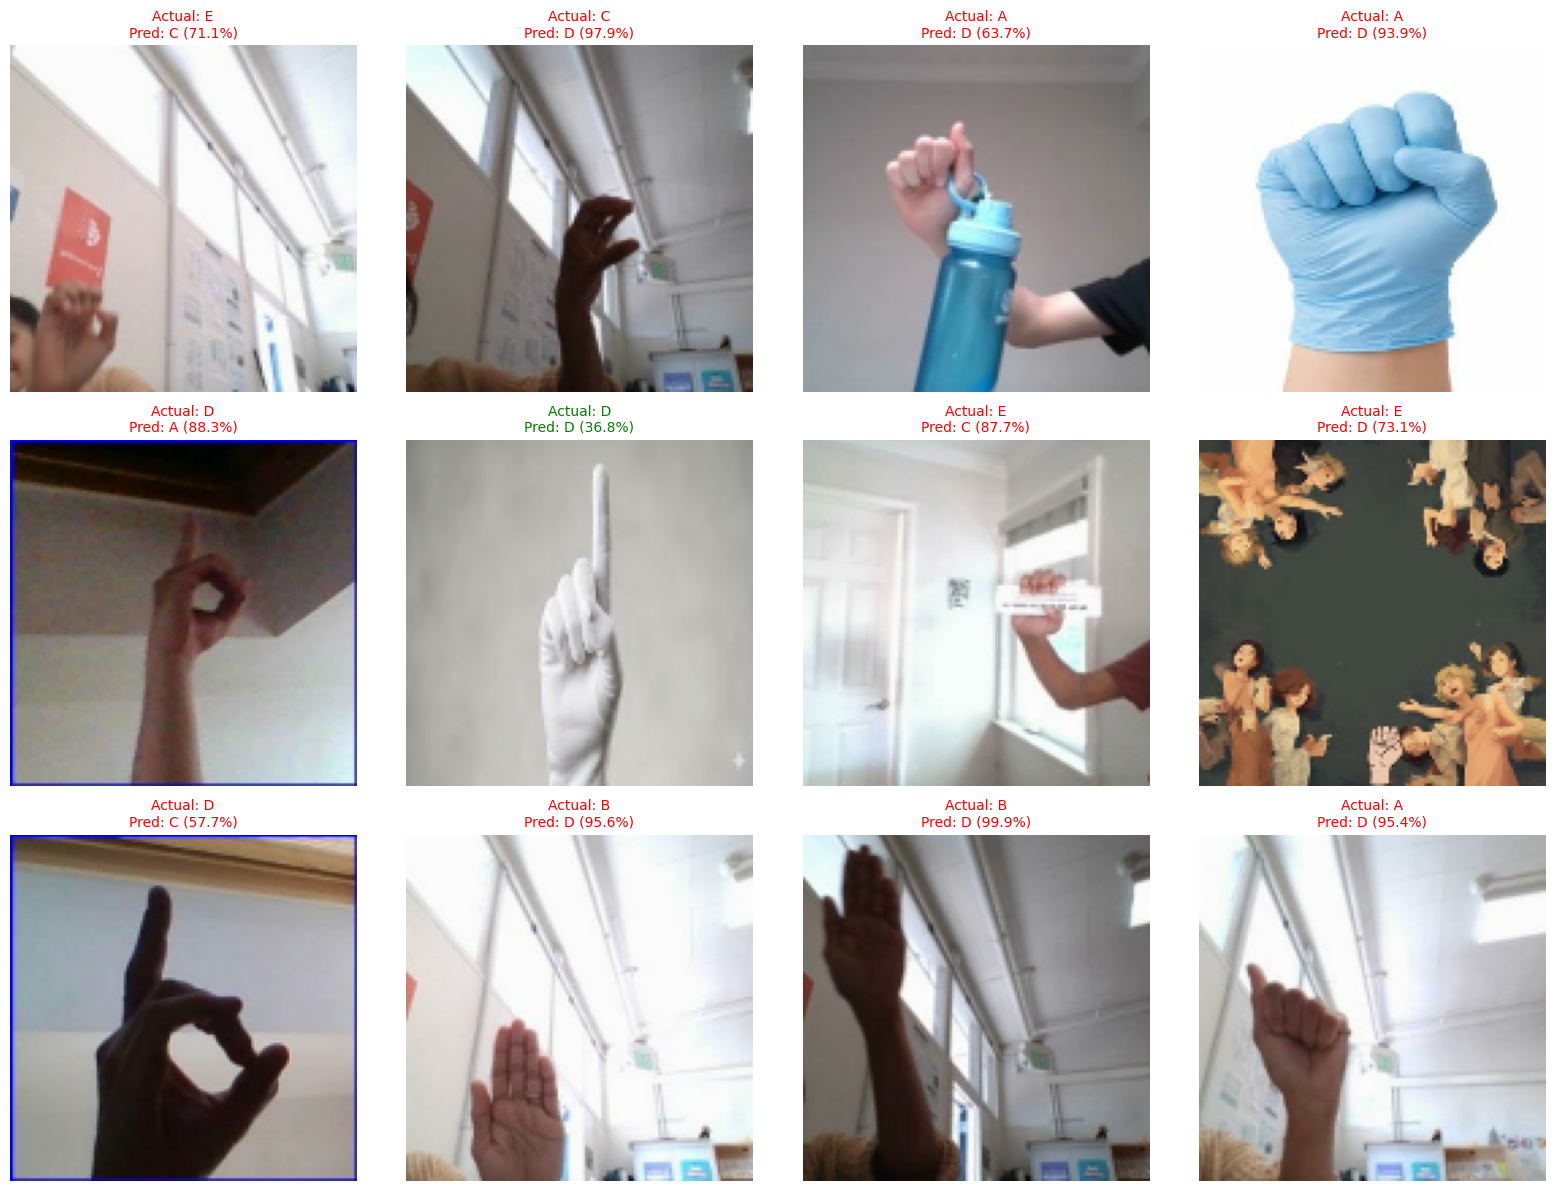

In [ ]:
# Cell 9: "Test" Dataset
eval_dir = '/content/drive/MyDrive/TEST_ASL'  # update this path
test_ds = tf.keras.utils.image_dataset_from_directory(
    eval_dir,
    image_size=(128, 128),
    label_mode='categorical',
    shuffle=True
)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

loss, acc, f1 = model.evaluate(test_ds)
print(f"Test accuracy: {acc*100:.2f}%")
print(f"Test F1 score: {f1:.4f}")

# 1. Get a batch of images and labels from the test set
# We use .take(1) to get one batch (usually 32 images)
for test_images, test_labels in test_ds.take(1):

    # 2. Generate predictions
    # The model outputs probabilities, so we use argmax to get the class index
    predictions = model.predict(test_images)

    plt.figure(figsize=(16, 12))

    # Show the first 12 images in the batch
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)

        # Display the image
        # If your images are already rescaled to 0-1, just show them
        # If they are 0-255, cast to uint8
        img = test_images[i].numpy()
        if np.max(img) <= 1.0:
            plt.imshow(img)
        else:
            plt.imshow(img.astype("uint8"))

        # Get the index of the actual and predicted class
        actual_idx = np.argmax(test_labels[i])
        pred_idx = np.argmax(predictions[i])

        actual_name = classes[actual_idx]
        pred_name = classes[pred_idx]
        confidence = predictions[i][pred_idx] * 100

        # Color code the title: Green for correct, Red for wrong
        title_color = 'green' if actual_idx == pred_idx else 'red'

        plt.title(f"Actual: {actual_name}\nPred: {pred_name} ({confidence:.1f}%)",
                  color=title_color, fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()